[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Multi-Head Attention and Positional Encoding

The previous notebook gave us plain self-attention where $\mathbf{Q} = \mathbf{K} = \mathbf{V} = \mathbf{X}$.  This notebooks provides two refinements to explain, which together account for the remaining structure inside an attention sublayer:

1. **Learned projections and multiple heads.**  The black box's `nhead=4` hyperparameter, and the reason attention can learn *what kind of* relatedness to look for.
2. **Positional encoding.**  The missing ingredient: notebook 1's model was provably order-blind — scrambling a review changed nothing.  Self-attention sees a set, so order must be written into the vectors themselves; here we build the standard fix.

As always, once we build our own version we verify it against PyTorch's — this time `nn.MultiheadAttention`, with weights copied over so the comparison is exact.

## Why learned projections?

With $\mathbf{Q} = \mathbf{K} = \mathbf{V} = \mathbf{X}$, the attention weights are determined by dot products *in the embedding space*: a position attends to positions whose embeddings point in a similar direction, and that's that.  The model has no say in what "similar" means.  It also creates an awkward bias: every position's query matches its own key perfectly, so each position mostly attends to itself.

The fix is to let the model *learn* the lookup structure.  Given a query $\mathbf{q} \in \mathbb{R}^{d_q}$, key $\mathbf{k} \in \mathbb{R}^{d_k}$, and value $\mathbf{v} \in \mathbb{R}^{d_v}$ (in self-attention, all three are the same input vector $\mathbf{x}$), we apply three learned linear maps $\mathbf{W}^{(q)}$, $\mathbf{W}^{(k)}$, $\mathbf{W}^{(v)}$ before the attention operation.  Now training can shape the projections so that, say, a negation word's *query* aligns with the *keys* of evaluative words — the "matches" that attention finds become whatever matches help the task.  The projections turn attention from a fixed similarity search into a trainable one.

## Why multiple heads?

One learned projection buys one notion of relatedness per layer.  But a token participates in several relationships at once: "not" in "not bad at all" is related to "bad" as the thing it negates, and to "at all" as an intensifier of the negation; a token may also need to track nearby words and long-range topic words simultaneously.  A single softmax-weighted average must compromise between these.

**Multi-head attention** runs $h$ attention operations in parallel, each with its *own* learned projections — each head its own notion of compatibility — and then concatenates the $h$ outputs and mixes them with one more learned map $\mathbf{W}^{(o)}$.  Formally, head $i$ computes

$$\mathbf{h}_i = f\big(\mathbf{W}_i^{(q)}\mathbf{q},\; \mathbf{W}_i^{(k)}\mathbf{k},\; \mathbf{W}_i^{(v)}\mathbf{v}\big) \in \mathbb{R}^{p_v},$$

where $f$ is scaled dot product attention and $\mathbf{W}_i^{(q)}\in\mathbb{R}^{p_q\times d_q}$, $\mathbf{W}_i^{(k)}\in\mathbb{R}^{p_k\times d_k}$, $\mathbf{W}_i^{(v)}\in\mathbb{R}^{p_v\times d_v}$ are that head's parameters.  The output is

$$\mathbf{W}^{(o)} \begin{bmatrix}\mathbf{h}_1\\\vdots\\\mathbf{h}_h\end{bmatrix} \in \mathbb{R}^{p_o}.$$

This operation is captured by the following figure:

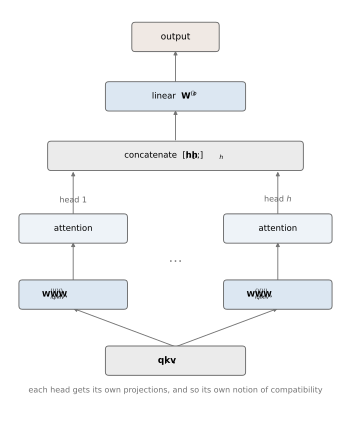

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import matplotlib.pyplot as plt

# palette shared with the rest of the course figures
KEY, VAL, OP, OUTC, DATA = '#dce7f2', '#e6dcea', '#eef3f8', '#f0e9e4', '0.92'
GREY, RED = '0.45', '#c1440e'

def multihead_figure():
    """h heads, each with its own projections, concatenated and mixed."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

    fig, ax = plt.subplots(figsize=(5.1, 5.7))
    PROJ, ATT = '#dce7f2', '#eef3f8'
    lanes = [-1.55, 0.0, 1.55]
    lane_note = ['head 1', '⋯', f'head $h$']
    y_in, y_proj, y_att, y_cat, y_lin, y_out = -2.35, -1.35, -0.35, 0.75, 1.65, 2.55
    bw, bh = 1.16, 0.42

    def box(xc, yc, text, fill, w=bw, h=bh, fs=8.5, dashed=False):
        ax.add_patch(FancyBboxPatch((xc - w / 2, yc - h / 2), w, h,
                                    boxstyle='round,pad=0.012,rounding_size=0.05',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=fill, zorder=3,
                                    linestyle=(0, (3, 2)) if dashed else '-'))
        ax.text(xc, yc, text, ha='center', va='center', fontsize=fs, zorder=4,
                linespacing=1.3)

    def arrow(x0, y0, x1, y1, color=GREY, lw=0.9):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                     mutation_scale=8, linewidth=lw,
                                     color=color, shrinkA=0, shrinkB=0,
                                     zorder=1))

    box(0.0, y_in, '$\\mathbf{q}$,  $\\mathbf{k}$,  $\\mathbf{v}$', DATA,
        w=2.10, fs=9)

    for x, note in zip(lanes, lane_note):
        middle = (x == 0.0)
        if middle:
            ax.text(x, (y_proj + y_att) / 2, '⋯', ha='center', va='center',
                    fontsize=14, color='0.5')
            continue
        box(x, y_proj, '$\\mathbf{W}^{(q)}_i$,  $\\mathbf{W}^{(k)}_i$,'
            '  $\\mathbf{W}^{(v)}_i$', PROJ, w=1.62, fs=7.6)
        box(x, y_att, 'attention', ATT, w=1.62)
        arrow(0.0, y_in + bh / 2, x, y_proj - bh / 2)
        arrow(x, y_proj + bh / 2, x, y_att - bh / 2)
        arrow(x, y_att + bh / 2, x, y_cat - 0.24)
        ax.text(x, y_att + bh / 2 + 0.16, note, ha='center', va='bottom',
                fontsize=8, color='0.4')

    box(0.0, y_cat, 'concatenate  $[\\mathbf{h}_1; \\ldots; \\mathbf{h}_h]$',
        '0.92', w=3.85, fs=8.5)
    arrow(0.0, y_cat + 0.24, 0.0, y_lin - bh / 2)
    box(0.0, y_lin, 'linear  $\\mathbf{W}^{(o)}$', PROJ, w=2.10, fs=8.5)
    arrow(0.0, y_lin + bh / 2, 0.0, y_out - bh / 2)
    box(0.0, y_out, 'output', OUTC, w=1.30, fs=9)

    ax.text(0.0, y_in - bh / 2 - 0.18,
            'each head gets its own projections, and so its own notion of '
            'compatibility',
            ha='center', va='top', fontsize=8, color='0.45')

    ax.set_xlim(-2.55, 2.55)
    ax.set_ylim(y_in - 0.85, y_out + 0.45)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

multihead_figure()

The standard sizing — used by the transformer paper and by PyTorch — makes the heads *split* the model dimension rather than multiply it: with model dimension $d_{\textrm{model}}$ (called `num_hiddens` below), each head works in dimension $p_q = p_k = p_v = d_{\textrm{model}}/h$.  Recall the attention maps in notebook 1: we averaged over 4 heads, each of which was a $25$-dimensional attention operation inside our $100$-dimensional model.  The total computation is roughly that of one full-width head, but the layer gets $h$ independent attention patterns.

## Implementation

The implementation's only subtlety is bookkeeping.  Rather than looping over heads (slow), we compute all head projections with one matrix each — a $d_{\textrm{model}} \times d_{\textrm{model}}$ matrix *is* $h$ stacked $d_{\textrm{model}}/h \times d_{\textrm{model}}$ head projections, and then reshape to expose the head as its own axis, giving tensors of shape `(batch, heads, seq, d_head)`.  Because the `attention` function from the previous notebook broadcasts over *any* leading axes, it computes all heads of all sequences in a single call on these rank-4 tensors with no need for reshaping down to rank 3 and no loop.

In [ ]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import math

import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt


def attention(Q, K, V):
    """Scaled dot product attention (notebook 3).  The last two axes are the
    matrices; any leading axes (batch, heads, ...) are broadcast over."""
    d = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


class MultiHeadAttention(nn.Module):
    """Multi-head attention with learned Q, K, V projections."""
    def __init__(self, num_hiddens, num_heads, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.W_q = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_k = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_v = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def split_heads(self, X):
        """(batch, seq, num_hiddens) -> (batch, heads, seq, num_hiddens/heads)"""
        b, seq, _ = X.shape
        X = X.reshape(b, seq, self.num_heads, -1)
        return X.transpose(1, 2)

    def merge_heads(self, X):
        """(batch, heads, seq, d_head) -> (batch, seq, num_hiddens)"""
        b, h, seq, d_head = X.shape
        return X.transpose(1, 2).reshape(b, seq, h * d_head)

    def forward(self, queries, keys, values):
        # project, then split into heads: each is (batch, heads, seq, d_head)
        Q = self.split_heads(self.W_q(queries))
        K = self.split_heads(self.W_k(keys))
        V = self.split_heads(self.W_v(values))
        # attention() broadcasts over the (batch, heads) leading axes
        output, self.attention_weights = attention(Q, K, V)
        return self.W_o(self.merge_heads(output))

A shape check: with keys and values of length 6 and queries of length 4, the output has one `num_hiddens`-dimensional vector per query, exactly like single-head attention — the heads are invisible from outside.

In [2]:
num_hiddens, num_heads = 100, 5
mha = MultiHeadAttention(num_hiddens, num_heads)   # not named `attention`:
# that name is the scaled-dot-product function this module calls internally
batch_size, num_queries, num_kvpairs = 2, 4, 6
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
out = mha(X, Y, Y)
print(out.shape)
assert out.shape == (batch_size, num_queries, num_hiddens)

torch.Size([2, 4, 100])


## Verification against `nn.MultiheadAttention`

PyTorch's `nn.MultiheadAttention` is the attention sublayer inside the `nn.TransformerEncoderLayer` we trained in notebook 1.  It stores the three projections stacked into a single `in_proj_weight` matrix (queries, keys, values in that order) and the output projection as `out_proj`.  We copy our weights into it, run both on the same input, and demand agreement:

In [3]:
torch.manual_seed(0)
mha_ours = MultiHeadAttention(num_hiddens, num_heads)
mha_torch = nn.MultiheadAttention(num_hiddens, num_heads, bias=False,
                                  batch_first=True)

# copy our parameters into the PyTorch module
with torch.no_grad():
    mha_torch.in_proj_weight.copy_(torch.cat([
        mha_ours.W_q.weight, mha_ours.W_k.weight, mha_ours.W_v.weight]))
    mha_torch.out_proj.weight.copy_(mha_ours.W_o.weight)

X = torch.randn(2, 9, num_hiddens)
ours = mha_ours(X, X, X)
theirs, _ = mha_torch(X, X, X)
print('max difference:', (ours - theirs).abs().max().item())
assert torch.allclose(ours, theirs, atol=1e-5)
print('match!')

max difference: 1.1920928955078125e-07
match!


Multi-head attention with learned projections is still built entirely from position-blind pieces: the projections act on each position independently, and the attention operation is permutation-equivariant.  So the equivariance we proved last notebook survives intact — shuffle the inputs and the outputs shuffle along:

In [4]:
n = 9
perm = torch.randperm(n)
out_then_perm = mha_ours(X, X, X)[:, perm]
perm_then_out = mha_ours(X[:, perm], X[:, perm], X[:, perm])
print('max difference:',
      (out_then_perm - perm_then_out).abs().max().item())
assert torch.allclose(out_then_perm, perm_then_out, atol=1e-5)
print('multi-head attention is still permutation-equivariant')

max difference: 8.940696716308594e-08
multi-head attention is still permutation-equivariant


## Positional encoding

Time to fix notebook 1's order-blindness.  The demonstration above is the diagnosis, made precise: any stack of multi-head attention layers maps "this movie is not bad" and a scrambled version of it to the same vectors, scrambled — so a classifier reading a summary of those vectors gets *identical* evidence for both word orders, which is exactly what the scrambling experiment showed.  Since the operations will not be made order-aware, the input must be: we add to each embedding a **positional encoding** vector $\mathbf{p}_i$ that depends only on the position $i$, making the content of each vector reflect *where* it is.  Two tokens of the same word at different positions now enter attention as different vectors, and the learned projections can extract position information whenever it is useful.

Positional encodings can be learned per position, but the transformer paper proposed a fixed sinusoidal scheme that needs no parameters and extends to any length.  With input $\mathbf{X} \in \mathbb{R}^{n \times d}$ holding the $d$-dimensional embeddings of $n$ tokens, we output $\mathbf{X} + \mathbf{P}$ where $\mathbf{P} \in \mathbb{R}^{n \times d}$ has entries

$$p_{i, 2j} = \sin\left(\frac{i}{10000^{2j/d}}\right), \qquad p_{i, 2j+1} = \cos\left(\frac{i}{10000^{2j/d}}\right).$$

Each *pair* of columns $(2j, 2j+1)$ is a sine–cosine pair at one frequency, and the frequencies decrease geometrically from column to column.  At first glance this looks arbitrary; the two subsections below unpack why it is a sensible way to write down a position.  First, the implementation.  From here on, this class is a standard part of our models — notebook 6's from-scratch transformer includes it, as does essentially every real transformer:

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding, added to the input embeddings."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # register_buffer: part of the module's state (moves with .to(device),
        # saved with the model) but not a trainable parameter
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, X):
        return X + self.pe[:, :X.size(1), :]

Adding the encoding breaks permutation equivariance, as intended — position is now part of the content:

In [6]:
pos_encoding = PositionalEncoding(num_hiddens)
X_pos = pos_encoding(X)
out_then_perm = mha_ours(X_pos, X_pos, X_pos)[:, perm]
Xp = pos_encoding(X[:, perm])
perm_then_out = mha_ours(Xp, Xp, Xp)
print('max difference:',
      (out_then_perm - perm_then_out).abs().max().item())

max difference: 0.09766130149364471


The difference is far from zero: shuffled input no longer produces merely-shuffled output, so downstream layers can distinguish word orders.

Let's look at what the encoding actually adds.  Below are four adjacent columns of $\mathbf{P}$ as functions of position.  Columns 6 and 7 form one sine–cosine pair, columns 8 and 9 the next pair at a lower frequency:

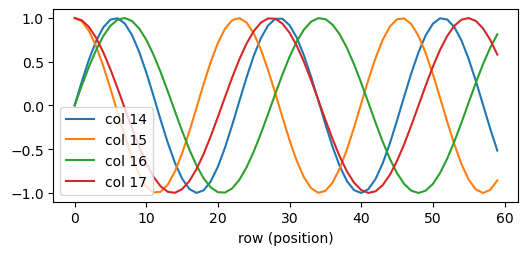

In [7]:
encoding_dim, num_steps = 32, 60
P = pos_encoding.pe[0, :num_steps, :encoding_dim]

plt.figure(figsize=(6, 2.5))
for col in range(14, 18):
    plt.plot(torch.arange(num_steps), P[:, col], label=f'col {col}')
plt.xlabel('row (position)'); plt.legend();

### Absolute positional information

Why do sinusoids at geometrically decreasing frequencies encode a position?  Because that is how *counting* works.  Look at the binary representations of consecutive integers: the lowest bit alternates every number, the next bit every two numbers, the next every four and so on:

In [8]:
for i in range(8):
    print(f'{i} in binary is {i:>03b}')

0 in binary is 000
1 in binary is 001
2 in binary is 010
3 in binary is 011
4 in binary is 100
5 in binary is 101
6 in binary is 110
7 in binary is 111


Each bit is a "square wave" over positions, with frequency halving from bit to bit, and together the bits pin down the number exactly.  The positional encoding is the continuous analogue: each column pair oscillates at its own frequency, high-frequency pairs distinguishing nearby positions and low-frequency pairs distinguishing distant ones.  The heatmap of $\mathbf{P}$ makes the resemblance visible — fast stripes in the low columns, slow waves in the high ones:

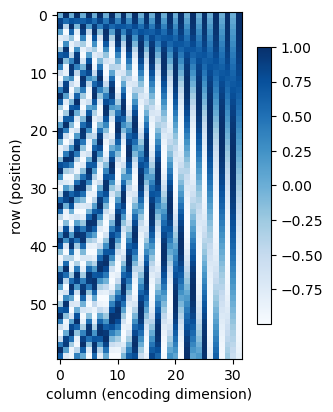

In [9]:
fig, ax = plt.subplots(figsize=(4, 4.5))
im = ax.imshow(P, cmap='Blues')
ax.set_xlabel('column (encoding dimension)')
ax.set_ylabel('row (position)')
fig.colorbar(im, shrink=0.8);

Unlike bits, the values are continuous — a smoother signal for a network than hard 0/1 transitions, and one that does not run out of columns for long sequences.

### Relative positions

Absolute position is one thing, but language often cares more about *relative* position — "the previous word", "three tokens back". The sinusoids carry this information as well.

Start with a picture. Take one column-pair, $(\sin i\omega_j,\ \cos i\omega_j)$: as the position $i$ increases, that point walks around a unit circle at a steady angular speed $\omega_j$ — a clock hand turning at a fixed rate, with the different pairs as hands running at geometrically spaced speeds. Advancing the position by an offset $\delta$ turns every hand by a fixed angle $\delta\omega_j$ — an amount that depends on $\delta$ but *not* on where you started. "Three positions later" is always the same set of turns.

Why should attention care? Because attention compares vectors with **dot products**, and the dot product of two points on a unit circle depends only on the angle between them. So the natural quantity to measure is the dot product between two positional encodings, $\mathrm{PE}(i)\cdot\mathrm{PE}(j)$, and to ask what it depends on. Let's just compute it for every pair of positions:

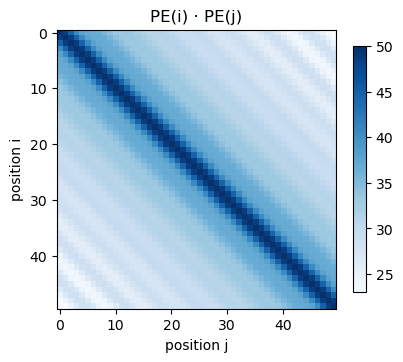

In [10]:
# every position gets a vector PE(i); how similar are two of them?
# compute the dot product between PE(i) and PE(j) for all pairs i, j.
pe = pos_encoding.pe[0]          # (max_len, d_model)
L = 50
G = pe[:L] @ pe[:L].T            # G[i, j] = PE(i) . PE(j)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(G, cmap='Blues', vmin=float(G.min()), vmax=float(G.max()))
ax.set_xlabel('position j'); ax.set_ylabel('position i')
ax.set_title('PE(i) · PE(j)')
fig.colorbar(im, shrink=0.8);

Look at the diagonals of the heatmap. Each diagonal is a fixed offset $j-i$, and along it the shade is constant: $\mathrm{PE}(i)\cdot\mathrm{PE}(j)$ depends only on *how far apart* the two positions are, not on where they sit in the sequence. The bright diagonal is offset $0$ — each encoding is most similar to itself — and the similarity falls off smoothly as the offset grows.

So the positional encoding hands the network a ready-made, translation-invariant **distance kernel**: a measure of how far apart any two tokens are that reads the same everywhere in the sequence. And because a head's queries and keys are *linear* functions of these encodings, it can pick that signal up and turn it into behaviours like "attend to my immediate neighbour" or "look three tokens back", entirely from relative position.

**Where the constant diagonals come from.** The clock-hand picture has an exact form worth seeing. Write $\omega_j = 10000^{-2j/d}$ for the angular speed of column-pair $j$. Advancing the position from $i$ to $i+\delta$ rotates that pair by the fixed angle $\delta\omega_j$:

$$\begin{bmatrix} p_{i+\delta,\,2j} \\ p_{i+\delta,\,2j+1} \end{bmatrix}
= \begin{bmatrix} \cos\delta\omega_j & \sin\delta\omega_j \\ -\sin\delta\omega_j & \cos\delta\omega_j \end{bmatrix}
\begin{bmatrix} p_{i,\,2j} \\ p_{i,\,2j+1} \end{bmatrix},$$

which is just the angle-addition identities for $\sin\!\big((i+\delta)\omega_j\big)$ and $\cos\!\big((i+\delta)\omega_j\big)$ written as a matrix. The rotation angle depends on the offset $\delta$ but not on the absolute position $i$ — the algebraic reason the dot product, and hence every diagonal of the heatmap, is constant. (Two vectors rotated by the same amount keep the same relative angle, so their dot product does not change.) The map is also *linear*, so the linear projections inside attention can reproduce it — the sense in which a head can "learn to look $\delta$ positions back".

This is what forces the encoding into sine–cosine **pairs**: a rotation acts on a two-dimensional vector, and $(\sin i\omega,\ \cos i\omega)$ is exactly that. A lone sine has nothing to rotate into — and worse, $\sin i\omega$ cannot even tell position $i$ from another position with the same sine. The pair pins the angle down without ambiguity and lets a shift of position act as a clean rotation, which is precisely what makes the dot product depend on the offset alone.

## Comparing CNNs, RNNs, and self-attention

With the mechanism now fully in view, we can make the architectural comparison from the start of the module quantitative.  Consider mapping a sequence of $n$ tokens, each a $d$-dimensional vector, to another such sequence, and compare three architectures on total computation, how many operations *must* run sequentially, and the maximum path length — the number of steps information needs to travel between the two most distant positions (shorter paths make long-range dependencies easier to learn).

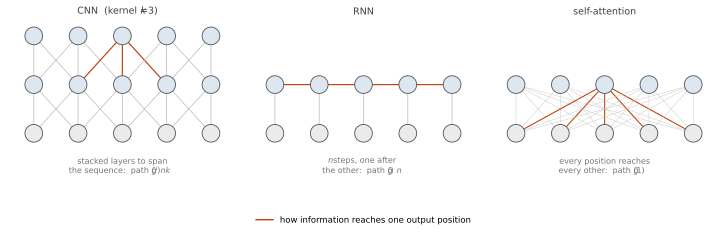

In [2]:
def cnn_rnn_attention_figure():
    """How information reaches position 4 in a CNN, an RNN, and self-attention."""
    from matplotlib.patches import Circle, FancyArrowPatch

    n = 5
    fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.4))
    titles = ['CNN  (kernel $k = 3$)', 'RNN', 'self-attention']
    notes = ['stacked layers to span\nthe sequence:  path $\\mathcal{O}(n/k)$',
             '$n$ steps, one after\nthe other:  path $\\mathcal{O}(n)$',
             'every position reaches\nevery other:  path $\\mathcal{O}(1)$']

    def token_row(ax, y, fill=DATA, r=0.20):
        for i in range(n):
            ax.add_patch(Circle((i, y), r, facecolor=fill, edgecolor='0.35',
                                linewidth=0.9, zorder=3))
        return r

    def link(ax, p0, p1, color=GREY, lw=0.9, curve=0.0):
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle='-|>',
                                     mutation_scale=7, linewidth=lw,
                                     color=color, shrinkA=3, shrinkB=3,
                                     zorder=2,
                                     connectionstyle=f'arc3,rad={curve}'))

    # ---- CNN: two stacked layers, kernel 3
    ax = axes[0]
    for lvl, y in enumerate((0.0, 1.1, 2.2)):
        token_row(ax, y, DATA if lvl == 0 else KEY)
    for y0, y1 in ((0.0, 1.1), (1.1, 2.2)):
        for i in range(n):
            for j in (i - 1, i, i + 1):
                if 0 <= j < n:
                    link(ax, (j, y0), (i, y1),
                         color=RED if (y1 == 2.2 and i == 2) else '0.72',
                         lw=1.2 if (y1 == 2.2 and i == 2) else 0.7)

    # ---- RNN: one chain
    ax = axes[1]
    token_row(ax, 0.0)
    token_row(ax, 1.1, KEY)
    for i in range(n):
        link(ax, (i, 0.0), (i, 1.1), color='0.72', lw=0.7)
    for i in range(n - 1):
        link(ax, (i, 1.1), (i + 1, 1.1), color=RED, lw=1.2)

    # ---- self-attention: all pairs into one position
    ax = axes[2]
    token_row(ax, 0.0)
    token_row(ax, 1.1, KEY)
    for i in range(n):
        for j in range(n):
            link(ax, (j, 0.0), (i, 1.1),
                 color=RED if i == 2 else '0.80',
                 lw=1.1 if i == 2 else 0.5)

    for ax, title, note in zip(axes, titles, notes):
        ax.set_title(title, fontsize=9.5, color='0.25')
        ax.text((n - 1) / 2, -0.55, note, ha='center', va='top', fontsize=8,
                color='0.45', linespacing=1.4)
        ax.set_xlim(-0.6, n - 0.4)
        ax.set_ylim(-1.10, 2.55)
        ax.set_aspect('equal')
        ax.axis('off')

    handle = axes[0].plot([], [], color=RED, linewidth=1.4,
                          label='how information reaches one output position')[0]
    fig.legend(handles=[handle], loc='lower center', fontsize=8.5,
               frameon=False, bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=(0, 0.07, 1, 1))

cnn_rnn_attention_figure()

A **convolutional layer** treating the text as a one-dimensional image, with kernel size $k$ and $d$ input and output channels, costs $\mathcal{O}(knd^2)$.  Convolutions are parallel across positions — $\mathcal{O}(1)$ sequential operations — but each layer only connects positions $k$ apart, so information needs a stack of $\mathcal{O}(n/k)$ layers to cross the sequence.

A **recurrent layer** multiplies a $d \times d$ weight matrix by the hidden state at each of $n$ steps: $\mathcal{O}(nd^2)$ total, which is the *least* computation of the three for long sequences.  But the $n$ steps are inherently sequential — this was our diagnosis in the speed experiment — and the maximum path length is $\mathcal{O}(n)$.

**Self-attention** computes $\mathbf{Q}\mathbf{K}^\top$ ($n \times d$ by $d \times n$) and multiplies the weights by $\mathbf{V}$: $\mathcal{O}(n^2 d)$.  In exchange, all positions are processed in parallel ($\mathcal{O}(1)$ sequential operations), and every token connects *directly* to every other token — maximum path length $\mathcal{O}(1)$.

| | computation | sequential ops | max path length |
|---|---|---|---|
| CNN | $\mathcal{O}(knd^2)$ | $\mathcal{O}(1)$ | $\mathcal{O}(n/k)$ |
| RNN | $\mathcal{O}(nd^2)$ | $\mathcal{O}(n)$ | $\mathcal{O}(n)$ |
| self-attention | $\mathcal{O}(n^2d)$ | $\mathcal{O}(1)$ | $\mathcal{O}(1)$ |

Self-attention buys full parallelism and one-hop information flow, and pays with the $n^2$ term — prohibitive for very long sequences, exactly as the timing exercise in notebook 1 shows.

## Summary

* Learned query/key/value projections turn attention's fixed dot-product similarity into a trainable notion of compatibility; multi-head attention runs $h$ such projections in parallel and mixes their outputs, letting one layer track several kinds of relationships at once.
* With the standard sizing, the heads split the model dimension ($d_{\textrm{model}}/h$ each), so multiple heads cost about the same as one full-width head.  Our implementation matches PyTorch's `nn.MultiheadAttention` exactly.
* Multi-head attention remains permutation-equivariant.  Sinusoidal positional encodings fix this by adding position-dependent patterns to the embeddings: geometrically spaced frequencies encode absolute position like a continuous binary counter, and sine–cosine pairs make relative offsets linearly recoverable.
* CNNs, RNNs, and self-attention trade off computation, parallelism, and path length; self-attention is the only one with both $\mathcal{O}(1)$ sequential operations and $\mathcal{O}(1)$ path length, at $\mathcal{O}(n^2 d)$ cost.


## Exercises

1. Suppose we want to prune the least important attention heads of a trained model to speed up prediction.  Design an experiment to measure how much each head matters.
2. Design a *learnable* positional encoding (hint: `nn.Embedding` over positions).  What are its advantages and disadvantages versus the sinusoidal scheme — in parameters, in behavior on sequences longer than any seen in training?
3. Why is the positional encoding *added* to the embedding rather than concatenated?  What would concatenation cost, and what must the model be able to do for addition not to destroy information?  (It may help that embeddings here are learned — the model can reserve "room" for the position signal.)
4. Retrofit the fix: add `PositionalEncoding` to notebook 1's `TransformerClassifier` (one line in `__init__`, one in `forward`) and retrain.  Evaluate both models on sentence pairs where word order flips the sentiment (exercise 5 of notebook 1) — where does the difference show up?